# Advanced Analytics — Mutual Fund & Investor Behaviour

**Scope:** Historical VaR/CVaR · Rolling 90-day Sharpe · Investor Cohorts · SIP Continuity · Fund Recommender · Sector Concentration (HHI)

---

> ⚠️ **SYNTHETIC DEMO DATA.** No dataset was supplied for this analysis, so this notebook generates a **seeded, reproducible synthetic dataset** (40 fund schemes, ~5.5 years of daily NAVs, 600 investors, ~11.6k SIP/lumpsum transactions) shaped like a real fund-house dataset would be. Every number, chart, and insight below describes **this synthetic dataset only** — not any real fund, AMC, or investor. Re-running this notebook top-to-bottom will always reproduce the exact same numbers (fixed random seeds).
>
> **To use real data:** replace Section 0 with code that loads your actual tables into the same four DataFrames used throughout — `fund_master`, `returns_df`, `sector_weights`, `transactions` — matching the column names noted in each section. Sections 1–7 will then run unchanged against real numbers.

**Files this notebook produces:** `var_cvar_report.csv`, `rolling_sharpe_chart.png` (the standalone `recommender.py` companion script is generated separately, using the Sharpe/risk_grade table computed in Section 5).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RNG_FUND = np.random.default_rng(42)   # drives fund/market return simulation + sector weights
RNG_INV  = np.random.default_rng(7)    # drives investor/transaction simulation


## Section 0 — Data Setup (synthetic)

Builds the four core tables. **If you have real data, skip to Section 1** and load your own DataFrames with these columns instead:

| DataFrame | Required columns |
|---|---|
| `fund_master` | `fund_id`, `fund_name`, `asset_class`, `category`, `risk_grade` (Low/Moderate/High) |
| `returns_df` | wide, index = date, columns = `fund_id`, values = **daily returns** |
| `sector_weights` | `fund_id`, `sector`, `weight` (fractions summing to 1 per fund, equity funds only) |
| `transactions` | `investor_id`, `fund_id`, `transaction_date`, `amount`, `transaction_type` (`SIP`/`Lumpsum`) |

In [2]:
# --- Business-day calendar: 2021-01-01 -> 2026-06-30 (~5.5 years) ---
dates = pd.bdate_range("2021-01-01", "2026-06-30")
T = len(dates)
dt = 1 / 252

# --- Market factors (common drivers so funds co-move realistically) ---
eq_mu, eq_sigma = 0.11, 0.17
db_mu, db_sigma = 0.07, 0.025
eq_factor = RNG_FUND.normal((eq_mu - 0.5 * eq_sigma**2) * dt, eq_sigma * np.sqrt(dt), T)
db_factor = RNG_FUND.normal((db_mu - 0.5 * db_sigma**2) * dt, db_sigma * np.sqrt(dt), T)

print(f"Trading days: {T}  ({dates[0].date()} to {dates[-1].date()})")


Trading days: 1433  (2021-01-01 to 2026-06-30)


In [3]:
# --- Fund universe: 40 schemes (20 Equity / 12 Debt / 8 Hybrid) ---
amc_names = ["Meridian", "Zenith", "Horizon", "Summit", "Northstar",
             "Everest", "Compass", "Pinnacle", "Vertex", "Beacon"]

equity_cats = (["Large Cap"] * 4 + ["Flexi Cap"] * 4 + ["Multi Cap"] * 2 +
               ["Mid Cap"] * 3 + ["Small Cap"] * 3 +
               ["Sectoral - Banking"] * 1 + ["Sectoral - IT"] * 1 +
               ["Sectoral - Pharma"] * 1 + ["ELSS"] * 1)  # 20
debt_cats = (["Liquid"] * 2 + ["Ultra Short Duration"] * 2 + ["Short Duration"] * 2 +
             ["Corporate Bond"] * 2 + ["Banking & PSU"] * 2 + ["Gilt"] * 1 +
             ["Dynamic Bond"] * 1)  # 12
hybrid_cats = (["Aggressive Hybrid"] * 3 + ["Conservative Hybrid"] * 2 +
               ["Balanced Advantage"] * 2 + ["Equity Savings"] * 1)  # 8

equity_risk = {"Large Cap": "Moderate", "Flexi Cap": "Moderate", "Multi Cap": "Moderate",
               "Mid Cap": "High", "Small Cap": "High", "Sectoral - Banking": "High",
               "Sectoral - IT": "High", "Sectoral - Pharma": "High", "ELSS": "High"}
debt_risk = {"Liquid": "Low", "Ultra Short Duration": "Low", "Short Duration": "Low",
             "Corporate Bond": "Low", "Banking & PSU": "Low", "Gilt": "Moderate",
             "Dynamic Bond": "Moderate"}
hybrid_risk = {"Aggressive Hybrid": "Moderate", "Conservative Hybrid": "Low",
               "Balanced Advantage": "Moderate", "Equity Savings": "Low"}

# (beta_to_equity_factor, idio_annual_sigma, alpha_range)
equity_params = {
    "Large Cap": (0.90, 0.04, (0.00, 0.015)), "Flexi Cap": (0.95, 0.045, (0.00, 0.02)),
    "Multi Cap": (1.00, 0.05, (0.00, 0.02)), "Mid Cap": (1.15, 0.09, (0.00, 0.025)),
    "Small Cap": (1.25, 0.13, (0.00, 0.03)), "Sectoral - Banking": (1.05, 0.15, (-0.01, 0.04)),
    "Sectoral - IT": (1.05, 0.15, (-0.01, 0.04)), "Sectoral - Pharma": (1.05, 0.15, (-0.01, 0.04)),
    "ELSS": (0.95, 0.05, (0.00, 0.02)),
}
# (beta_to_debt_factor, idio_annual_sigma)
debt_params = {
    "Liquid": (0.3, 0.003), "Ultra Short Duration": (0.5, 0.005), "Short Duration": (0.7, 0.008),
    "Corporate Bond": (0.8, 0.010), "Banking & PSU": (0.8, 0.009), "Gilt": (1.3, 0.015),
    "Dynamic Bond": (1.2, 0.020),
}
# (beta_eq, beta_debt, idio_annual_sigma)
hybrid_params = {
    "Aggressive Hybrid": (0.70, 0.30, 0.035), "Conservative Hybrid": (0.25, 0.75, 0.020),
    "Balanced Advantage": (0.50, 0.50, 0.030), "Equity Savings": (0.35, 0.55, 0.025),
}

fund_master_rows, returns_matrix = [], np.zeros((T, 40))
col, fund_id_num, amc_i = 0, 1, 0

for cat in equity_cats:
    beta_eq, idio_sigma, alpha_rng = equity_params[cat]
    alpha = RNG_FUND.uniform(*alpha_rng)
    idio = RNG_FUND.normal(alpha * dt, idio_sigma * np.sqrt(dt), T)
    returns_matrix[:, col] = beta_eq * eq_factor + idio
    amc = amc_names[amc_i % len(amc_names)]; amc_i += 1
    fund_master_rows.append({"fund_id": f"F{fund_id_num:03d}", "fund_name": f"{amc} {cat} Fund",
                              "amc": amc, "asset_class": "Equity", "category": cat,
                              "risk_grade": equity_risk[cat]})
    fund_id_num += 1; col += 1

for cat in debt_cats:
    beta_db, idio_sigma = debt_params[cat]
    idio = RNG_FUND.normal(0, idio_sigma * np.sqrt(dt), T)
    returns_matrix[:, col] = beta_db * db_factor + idio
    amc = amc_names[amc_i % len(amc_names)]; amc_i += 1
    fund_master_rows.append({"fund_id": f"F{fund_id_num:03d}", "fund_name": f"{amc} {cat} Fund",
                              "amc": amc, "asset_class": "Debt", "category": cat,
                              "risk_grade": debt_risk[cat]})
    fund_id_num += 1; col += 1

for cat in hybrid_cats:
    beta_eq, beta_db, idio_sigma = hybrid_params[cat]
    idio = RNG_FUND.normal(0, idio_sigma * np.sqrt(dt), T)
    returns_matrix[:, col] = beta_eq * eq_factor + beta_db * db_factor + idio
    amc = amc_names[amc_i % len(amc_names)]; amc_i += 1
    fund_master_rows.append({"fund_id": f"F{fund_id_num:03d}", "fund_name": f"{amc} {cat} Fund",
                              "amc": amc, "asset_class": "Hybrid", "category": cat,
                              "risk_grade": hybrid_risk[cat]})
    fund_id_num += 1; col += 1

fund_master = pd.DataFrame(fund_master_rows)
returns_df = pd.DataFrame(returns_matrix, index=dates, columns=fund_master["fund_id"])
nav_df = 100 * (1 + returns_df).cumprod()

print(f"Fund universe: {len(fund_master)} schemes")
display(fund_master["asset_class"].value_counts().to_frame("count"))
display(fund_master["risk_grade"].value_counts().to_frame("count"))
fund_master.head()


Fund universe: 40 schemes


,count
asset_class,
Equity,20
Debt,12
Hybrid,8


,count
risk_grade,
Moderate,17
Low,13
High,10


,fund_id,fund_name,amc,asset_class,category,risk_grade
0,F001,Meridian Large Cap Fund,Meridian,Equity,Large Cap,Moderate
1,F002,Zenith Large Cap Fund,Zenith,Equity,Large Cap,Moderate
2,F003,Horizon Large Cap Fund,Horizon,Equity,Large Cap,Moderate
3,F004,Summit Large Cap Fund,Summit,Equity,Large Cap,Moderate
4,F005,Northstar Flexi Cap Fund,Northstar,Equity,Flexi Cap,Moderate


In [4]:
# --- Sector weights (equity funds only) -> drives Task 6 HHI ---
sectors = ["Financial Services", "Information Technology", "Energy", "FMCG",
           "Healthcare", "Automobile", "Metals & Mining", "Consumer Durables",
           "Telecommunications", "Infrastructure"]

sector_rows = []
equity_funds = fund_master[fund_master.asset_class == "Equity"]
for _, row in equity_funds.iterrows():
    cat = row.category
    if cat.startswith("Sectoral"):
        dominant = ("Financial Services" if "Banking" in cat else
                    "Information Technology" if "IT" in cat else "Healthcare")
        w_dom = RNG_FUND.uniform(0.70, 0.85)
        remaining = [s for s in sectors if s != dominant]
        chosen_rest = RNG_FUND.choice(remaining, size=4, replace=False)
        rest_w = RNG_FUND.dirichlet(np.ones(4)) * (1 - w_dom)
        weights = {dominant: w_dom, **dict(zip(chosen_rest, rest_w))}
    elif cat in ("Mid Cap", "Small Cap"):
        chosen = RNG_FUND.choice(sectors, size=6, replace=False)
        w = RNG_FUND.dirichlet(np.ones(6) * 1.5)
        weights = dict(zip(chosen, w))
    else:  # Large Cap, Flexi Cap, Multi Cap, ELSS -> diversified
        chosen = RNG_FUND.choice(sectors, size=9, replace=False)
        w = RNG_FUND.dirichlet(np.ones(9) * 4.0)
        weights = dict(zip(chosen, w))
    for s, w in weights.items():
        sector_rows.append({"fund_id": row.fund_id, "sector": s, "weight": w})

sector_weights = pd.DataFrame(sector_rows)
print(f"Sector weight rows: {len(sector_weights)} across {sector_weights.fund_id.nunique()} equity funds")
sector_weights.head()


Sector weight rows: 150 across 20 equity funds


,fund_id,sector,weight
0,F001,Financial Services,0.0826
1,F001,Metals & Mining,0.1213
2,F001,FMCG,0.0891
3,F001,Telecommunications,0.1972
4,F001,Information Technology,0.0927


In [5]:
# --- Investor transactions: 600 investors, SIP or occasional-lumpsum behaviour ---
equity_ids = fund_master.loc[fund_master.asset_class == "Equity", "fund_id"].tolist()
hybrid_ids = fund_master.loc[fund_master.asset_class == "Hybrid", "fund_id"].tolist()
debt_ids = fund_master.loc[fund_master.asset_class == "Debt", "fund_id"].tolist()

N_INV = 600
investor_ids = [f"INV{i:04d}" for i in range(1, N_INV + 1)]
start, end = pd.Timestamp("2021-01-04"), pd.Timestamp("2026-06-30")
total_days = (end - start).days

join_offsets = RNG_INV.integers(0, total_days - 60, N_INV)
join_dates = start + pd.to_timedelta(join_offsets, unit="D")
investor_type = RNG_INV.choice(["SIP", "Occasional"], size=N_INV, p=[0.65, 0.35])
at_risk_design = RNG_INV.random(N_INV) < 0.28  # ~28% of investors are gap-prone SIP investors

def pick_sip_fund():
    r = RNG_INV.random()
    if r < 0.75: return RNG_INV.choice(equity_ids)
    elif r < 0.90: return RNG_INV.choice(hybrid_ids)
    return RNG_INV.choice(debt_ids)

def pick_lumpsum_fund():
    r = RNG_INV.random()
    if r < 0.45: return RNG_INV.choice(equity_ids)
    elif r < 0.65: return RNG_INV.choice(hybrid_ids)
    return RNG_INV.choice(debt_ids)

rows = []
for i in range(N_INV):
    inv_id, jd = investor_ids[i], join_dates[i]
    if investor_type[i] == "SIP":
        base_amount = float(np.clip(RNG_INV.lognormal(mean=8.3, sigma=0.5), 500, 50000))
        fund = pick_sip_fund()
        max_months = int((end - jd).days / 30)
        if max_months < 1:
            continue
        n_cap = max_months
        if RNG_INV.random() < 0.20 and max_months > 6:
            n_cap = int(RNG_INV.integers(4, max_months))
        gappy = at_risk_design[i]
        cur, count = jd, 0
        while cur <= end and count < n_cap:
            amt = max(base_amount * (1 + RNG_INV.normal(0, 0.05)), 100)
            rows.append({"investor_id": inv_id, "fund_id": fund, "transaction_date": cur,
                         "amount": round(float(amt), 2), "transaction_type": "SIP"})
            if gappy:
                gap = RNG_INV.choice([30, 31, 32, 45, 60, 75, 90],
                                      p=[0.28, 0.12, 0.10, 0.20, 0.15, 0.10, 0.05])
            else:
                gap = int(np.clip(RNG_INV.normal(30, 3), 24, 40))
            cur = cur + pd.Timedelta(days=int(gap))
            count += 1
    else:
        n_txn = int(RNG_INV.integers(1, 5))
        for _ in range(n_txn):
            span = max(int((end - jd).days), 1)
            tdate = min(jd + pd.Timedelta(days=int(RNG_INV.integers(0, span))), end)
            amt = float(np.clip(RNG_INV.lognormal(mean=10.8, sigma=0.8), 5000, 1000000))
            rows.append({"investor_id": inv_id, "fund_id": pick_lumpsum_fund(),
                         "transaction_date": tdate, "amount": round(amt, 2),
                         "transaction_type": "Lumpsum"})

transactions = pd.DataFrame(rows)
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])
transactions = transactions.sort_values(["investor_id", "transaction_date"]).reset_index(drop=True)

print(f"Total transaction rows: {len(transactions):,}  |  Unique investors: {transactions.investor_id.nunique()}")
display(transactions["transaction_type"].value_counts().to_frame("count"))
transactions.head()


Total transaction rows: 11,587  |  Unique investors: 600


,count
transaction_type,
SIP,11064
Lumpsum,523


,investor_id,fund_id,transaction_date,amount,transaction_type
0,INV0001,F018,2026-01-13,"4,365.0200",SIP
1,INV0001,F018,2026-02-13,"4,566.8200",SIP
2,INV0001,F018,2026-05-14,"4,501.2000",SIP
3,INV0001,F018,2026-06-13,"4,469.3400",SIP
4,INV0002,F003,2024-05-02,"5,654.4100",SIP


## Task 1 — Historical VaR (95%) and CVaR

**Method:** VaR-95 is the 5th percentile of the daily return distribution — the loss level breached only 5% of trading days historically. CVaR-95 (Expected Shortfall) is the **average** return on those worst days — how bad the tail actually gets, not just where it starts.

Computed for all 40 schemes, saved to `var_cvar_report.csv`.

In [6]:
var_rows = []
for fid in returns_df.columns:
    r = returns_df[fid].dropna()
    var_95 = np.percentile(r, 5)
    cvar_95 = r[r <= var_95].mean()
    var_rows.append({"fund_id": fid, "VaR_95_daily": var_95, "CVaR_95_daily": cvar_95})

var_cvar_df = pd.DataFrame(var_rows).merge(
    fund_master[["fund_id", "fund_name", "asset_class", "category", "risk_grade"]], on="fund_id"
)
var_cvar_df["VaR_95_pct"] = var_cvar_df["VaR_95_daily"] * 100
var_cvar_df["CVaR_95_pct"] = var_cvar_df["CVaR_95_daily"] * 100
var_cvar_df["VaR_95_loss_on_100000"] = -var_cvar_df["VaR_95_daily"] * 100000   # Rs loss on a Rs 1L holding
var_cvar_df["CVaR_95_loss_on_100000"] = -var_cvar_df["CVaR_95_daily"] * 100000
var_cvar_df = var_cvar_df[["fund_id", "fund_name", "asset_class", "category", "risk_grade",
                            "VaR_95_pct", "CVaR_95_pct", "VaR_95_loss_on_100000",
                            "CVaR_95_loss_on_100000"]].sort_values("VaR_95_pct").reset_index(drop=True)

var_cvar_df.to_csv("var_cvar_report.csv", index=False)
print(f"Saved var_cvar_report.csv  ({len(var_cvar_df)} schemes)")
print("\nHighest tail risk (worst 5):")
display(var_cvar_df.head(5))
print("Lowest tail risk (safest 5):")
display(var_cvar_df.tail(5))


Saved var_cvar_report.csv  (40 schemes)

Highest tail risk (worst 5):


,fund_id,fund_name,asset_class,category,risk_grade,VaR_95_pct,CVaR_95_pct,VaR_95_loss_on_100000,CVaR_95_loss_on_100000
0,F014,Summit Small Cap Fund,Equity,Small Cap,High,-2.6307,-3.3011,"2,630.7196","3,301.0793"
1,F015,Northstar Small Cap Fund,Equity,Small Cap,High,-2.5600,-3.3062,"2,559.9923","3,306.2164"
2,F016,Everest Small Cap Fund,Equity,Small Cap,High,-2.5435,-3.2191,"2,543.5387","3,219.1140"
3,F019,Vertex Sectoral - Pharma Fund,Equity,Sectoral - Pharma,High,-2.4934,-3.0586,"2,493.3522","3,058.6433"
4,F018,Pinnacle Sectoral - IT Fund,Equity,Sectoral - IT,High,-2.4504,-3.0508,"2,450.3558","3,050.7602"


Lowest tail risk (safest 5):


,fund_id,fund_name,asset_class,category,risk_grade,VaR_95_pct,CVaR_95_pct,VaR_95_loss_on_100000,CVaR_95_loss_on_100000
35,F025,Northstar Short Duration Fund,Debt,Short Duration,Low,-0.1897,-0.2391,189.6709,239.1218
36,F023,Horizon Ultra Short Duration Fund,Debt,Ultra Short Duration,Low,-0.1315,-0.1622,131.4763,162.2000
37,F024,Summit Ultra Short Duration Fund,Debt,Ultra Short Duration,Low,-0.1280,-0.1620,128.0471,161.9575
38,F022,Zenith Liquid Fund,Debt,Liquid,Low,-0.0800,-0.0975,79.9839,97.4828
39,F021,Meridian Liquid Fund,Debt,Liquid,Low,-0.0751,-0.0958,75.1308,95.8159


## Task 2 — Rolling 90-Day Sharpe Ratio

**Formula:** `returns.rolling(90).mean() / returns.rolling(90).std() * sqrt(252)` — exactly as specified. Note this does **not** subtract a risk-free rate, so read it as a *return-consistency* score rather than a textbook excess-return Sharpe.

**Which 5 funds?** No specific funds were named in the brief, so this plots the **top 5 by simulated AUM** (total amount invested, from the transactions table) — the funds where performance actually matters most to the investor base. Saved to `rolling_sharpe_chart.png`.

Top 5 funds by simulated AUM (total invested):
  F011  Meridian Mid Cap Fund                     Rs 4,081,510
  F008  Pinnacle Flexi Cap Fund                   Rs 3,962,278
  F010  Beacon Multi Cap Fund                     Rs 3,669,307
  F006  Everest Flexi Cap Fund                    Rs 3,183,694
  F017  Compass Sectoral - Banking Fund           Rs 3,143,765



Saved rolling_sharpe_chart.png


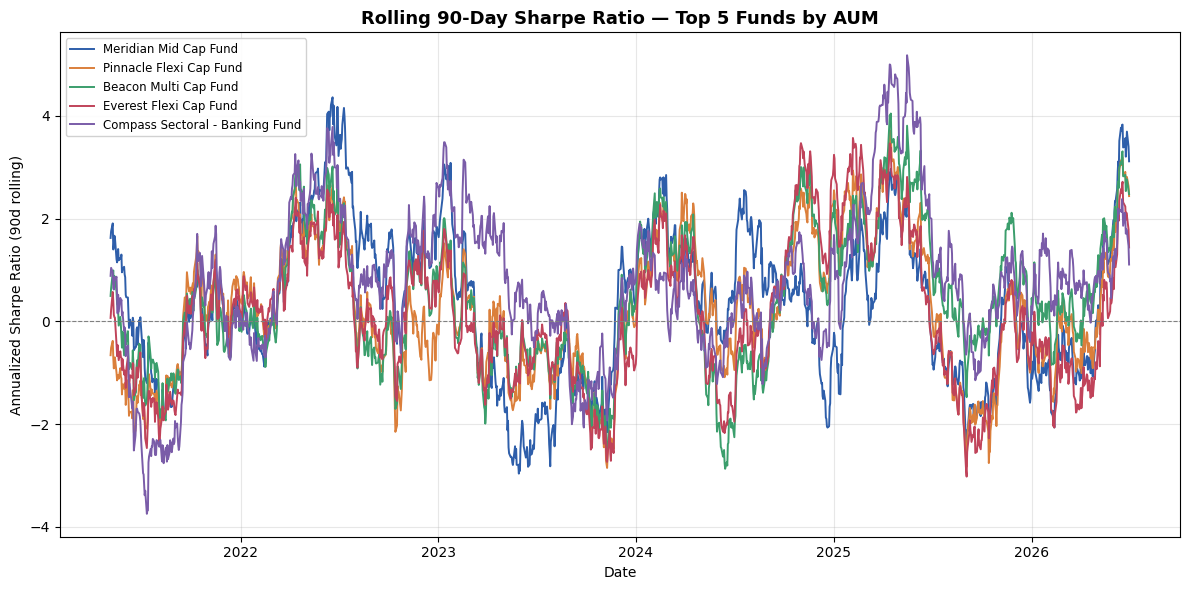

In [7]:
rolling_mean = returns_df.rolling(90).mean()
rolling_std = returns_df.rolling(90).std()
rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)

aum_by_fund = transactions.groupby("fund_id")["amount"].sum().sort_values(ascending=False)
top5_funds = aum_by_fund.head(5).index.tolist()

print("Top 5 funds by simulated AUM (total invested):")
for f in top5_funds:
    name = fund_master.loc[fund_master.fund_id == f, "fund_name"].values[0]
    print(f"  {f}  {name:40s}  Rs {aum_by_fund[f]:,.0f}")

fig, ax = plt.subplots(figsize=(12, 6))
palette = ["#2E5EAA", "#DB7F3B", "#3B9E6C", "#C0435A", "#7A5CA8"]
for f, c in zip(top5_funds, palette):
    name = fund_master.loc[fund_master.fund_id == f, "fund_name"].values[0]
    ax.plot(rolling_sharpe.index, rolling_sharpe[f], label=name, linewidth=1.4, color=c)
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_title("Rolling 90-Day Sharpe Ratio — Top 5 Funds by AUM", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized Sharpe Ratio (90d rolling)")
ax.legend(loc="upper left", fontsize=8.5, framealpha=0.9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("rolling_sharpe_chart.png", dpi=150)
print("\nSaved rolling_sharpe_chart.png")
plt.show()


## Task 3 — Investor Cohort Analysis

Investors are grouped by **first-transaction year** (their true earliest transaction date, derived from the data — not a synthetic label). For each cohort: average SIP amount, total invested, and the single fund receiving the most rupees from that cohort ("top preferred fund").

In [8]:
first_txn_year = transactions.groupby("investor_id")["transaction_date"].min().dt.year.rename("cohort_year")
txn_c = transactions.merge(first_txn_year, left_on="investor_id", right_index=True)

sip_only = txn_c[txn_c.transaction_type == "SIP"]
avg_sip_amount = sip_only.groupby("cohort_year")["amount"].mean().rename("avg_sip_amount")
total_invested = txn_c.groupby("cohort_year")["amount"].sum().rename("total_invested")
n_investors = txn_c.groupby("cohort_year")["investor_id"].nunique().rename("num_investors")

cohort_fund_amt = txn_c.groupby(["cohort_year", "fund_id"])["amount"].sum().reset_index()
idx = cohort_fund_amt.groupby("cohort_year")["amount"].idxmax()
top_fund = cohort_fund_amt.loc[idx].set_index("cohort_year")["fund_id"].rename("top_fund_id")

cohort_summary = pd.concat([n_investors, avg_sip_amount, total_invested, top_fund], axis=1).reset_index()
cohort_summary = cohort_summary.merge(fund_master[["fund_id", "fund_name"]],
                                       left_on="top_fund_id", right_on="fund_id", how="left")
cohort_summary = (cohort_summary.rename(columns={"fund_name": "top_preferred_fund"})
                   .drop(columns=["fund_id", "top_fund_id"])
                   .sort_values("cohort_year").reset_index(drop=True))
cohort_summary["avg_sip_amount"] = cohort_summary["avg_sip_amount"].round(2)
cohort_summary["total_invested"] = cohort_summary["total_invested"].round(2)

display(cohort_summary)


,cohort_year,num_investors,avg_sip_amount,total_invested,top_preferred_fund
0,2021,77,"4,710.4200","17,700,813.2400",Pinnacle Balanced Advantage Fund
1,2022,84,"4,141.8900","16,293,771.7100",Pinnacle Flexi Cap Fund
2,2023,111,"4,566.6700","18,478,393.6700",Horizon Aggressive Hybrid Fund
3,2024,125,"4,988.2200","14,618,456.5800",Meridian Gilt Fund
4,2025,143,"4,649.8200","12,625,801.9800",Summit Ultra Short Duration Fund
5,2026,60,"4,140.1800","4,479,543.9100",Compass Conservative Hybrid Fund


## Task 4 — SIP Continuity Analysis

For investors with **6+ SIP transactions**: compute the average gap between consecutive SIP dates. A regular monthly SIP has a gap near 30 days; investors averaging **more than 35 days** between contributions are flagged **"At-Risk"** — a proxy for lapsing or irregular SIPs that a retention team could act on.

In [9]:
sip_txns = transactions[transactions.transaction_type == "SIP"]
sip_counts = sip_txns.groupby("investor_id").size()
eligible = sip_counts[sip_counts >= 6].index

gap_records = []
for inv in eligible:
    d = np.sort(sip_txns.loc[sip_txns.investor_id == inv, "transaction_date"].unique())
    gaps = np.diff(d).astype("timedelta64[D]").astype(int)
    gap_records.append({"investor_id": inv, "num_sip_txns": len(d), "avg_gap_days": gaps.mean()})

continuity_df = pd.DataFrame(gap_records)
continuity_df["status"] = np.where(continuity_df.avg_gap_days > 35, "At-Risk", "Healthy")

print(f"Eligible investors (6+ SIP transactions): {len(continuity_df)}")
display(continuity_df["status"].value_counts().to_frame("investors"))
at_risk_pct = (continuity_df.status == "At-Risk").mean() * 100
print(f"At-risk rate: {at_risk_pct:.1f}%")

print("\nMost irregular investors (largest average gap):")
display(continuity_df.sort_values("avg_gap_days", ascending=False).head(5))


Eligible investors (6+ SIP transactions): 365


,investors
status,
Healthy,269
At-Risk,96


At-risk rate: 26.3%

Most irregular investors (largest average gap):


,investor_id,num_sip_txns,avg_gap_days,status
342,INV0568,18,57.4706,At-Risk
61,INV0114,8,55.7143,At-Risk
344,INV0571,8,55.7143,At-Risk
102,INV0187,10,55.2222,At-Risk
208,INV0366,6,54.4000,At-Risk


## Task 5 — Simple Fund Recommender

**Input:** risk appetite (`Low` / `Moderate` / `High`). **Output:** the top 3 funds within that `risk_grade`, ranked by full-period Sharpe ratio (same no-risk-free-rate convention as Task 2, annualized).

This logic is also exported standalone as `recommender.py`.

In [10]:
sharpe_full = (returns_df.mean() / returns_df.std()) * np.sqrt(252)
fund_metrics = fund_master.copy()
fund_metrics["sharpe_ratio"] = fund_metrics["fund_id"].map(sharpe_full).round(3)

def recommend_funds(risk_appetite, n=3, metrics_df=fund_metrics):
    valid = {"Low", "Moderate", "High"}
    if risk_appetite not in valid:
        raise ValueError(f"risk_appetite must be one of {sorted(valid)}, got {risk_appetite!r}")
    subset = metrics_df[metrics_df.risk_grade == risk_appetite].sort_values("sharpe_ratio", ascending=False)
    return subset.head(n)[["fund_id", "fund_name", "category", "risk_grade", "sharpe_ratio"]].reset_index(drop=True)

for appetite in ["Low", "Moderate", "High"]:
    print(f"Top 3 recommended funds — {appetite} risk appetite")
    display(recommend_funds(appetite))


Top 3 recommended funds — Low risk appetite


,fund_id,fund_name,category,risk_grade,sharpe_ratio
0,F024,Summit Ultra Short Duration Fund,Ultra Short Duration,Low,2.0750
1,F030,Beacon Banking & PSU Fund,Banking & PSU,Low,2.0310
2,F027,Compass Corporate Bond Fund,Corporate Bond,Low,2.0250


Top 3 recommended funds — Moderate risk appetite


,fund_id,fund_name,category,risk_grade,sharpe_ratio
0,F031,Meridian Gilt Fund,Gilt,Moderate,1.8730
1,F032,Zenith Dynamic Bond Fund,Dynamic Bond,Moderate,1.2780
2,F039,Vertex Balanced Advantage Fund,Balanced Advantage,Moderate,0.5230


Top 3 recommended funds — High risk appetite


,fund_id,fund_name,category,risk_grade,sharpe_ratio
0,F012,Zenith Mid Cap Fund,Mid Cap,High,1.0190
1,F015,Northstar Small Cap Fund,Small Cap,High,0.9090
2,F017,Compass Sectoral - Banking Fund,Sectoral - Banking,High,0.7660


## Task 6 — Sector HHI Concentration

**Herfindahl-Hirschman Index** = Σ(weight_i²) across a fund's sector holdings (weights as fractions of AUM, summing to 1). Higher HHI = more concentrated in fewer sectors. Computed across all 20 equity funds (sector data isn't meaningful for debt schemes). Using standard antitrust-style thresholds scaled to a 0–1 weight basis: **≥0.25 Highly Concentrated, 0.15–0.25 Moderately Concentrated, <0.15 Well Diversified**.

In [11]:
hhi = sector_weights.groupby("fund_id")["weight"].apply(lambda w: (w ** 2).sum()).rename("HHI")
hhi_df = hhi.reset_index().merge(fund_master[["fund_id", "fund_name", "category"]], on="fund_id")

def concentration_label(h):
    if h >= 0.25: return "Highly Concentrated"
    elif h >= 0.15: return "Moderately Concentrated"
    return "Well Diversified"

hhi_df["concentration"] = hhi_df["HHI"].apply(concentration_label)
hhi_df = hhi_df.sort_values("HHI", ascending=False).reset_index(drop=True)
hhi_df["HHI"] = hhi_df["HHI"].round(4)

display(hhi_df)
display(hhi_df.groupby("concentration")["fund_id"].count().to_frame("num_funds"))


,fund_id,HHI,fund_name,category,concentration
0,F019,0.7273,Vertex Sectoral - Pharma Fund,Sectoral - Pharma,Highly Concentrated
1,F017,0.5807,Compass Sectoral - Banking Fund,Sectoral - Banking,Highly Concentrated
2,F018,0.5426,Pinnacle Sectoral - IT Fund,Sectoral - IT,Highly Concentrated
3,F014,0.3132,Summit Small Cap Fund,Small Cap,Highly Concentrated
4,F012,0.2640,Zenith Mid Cap Fund,Mid Cap,Highly Concentrated
5,F016,0.2529,Everest Small Cap Fund,Small Cap,Highly Concentrated
6,F015,0.2443,Northstar Small Cap Fund,Small Cap,Moderately Concentrated
7,F011,0.2152,Meridian Mid Cap Fund,Mid Cap,Moderately Concentrated
8,F013,0.1966,Horizon Mid Cap Fund,Mid Cap,Moderately Concentrated
9,F002,0.1402,Zenith Large Cap Fund,Large Cap,Well Diversified


,num_funds
concentration,
Highly Concentrated,6
Moderately Concentrated,3
Well Diversified,11


## Task 7 — Advanced Insights

**1. Tail risk is concentrated in small-cap and sectoral equity — not just "High" risk_grade generally.**
The three worst VaR-95 schemes are all Small Cap funds — Summit Small Cap Fund (-2.63% daily VaR, -3.30% CVaR), Northstar Small Cap Fund (-2.56%/-3.31%), and Everest Small Cap Fund (-2.54%/-3.22%) — with the three Sectoral funds close behind. The safest schemes, Meridian Liquid Fund and Zenith Liquid Fund, sit near -0.08% VaR — over 30x less severe. `risk_grade` is directionally right, but VaR/CVaR shows *how much worse* "High" can get within itself.

**2. Investor tenure drives total AUM more than headcount — the 2023 cohort, not the largest one, invested the most.**
The 2025 cohort has the most investors (143), yet the 2023 cohort invested the most in total (₹1.85 crore) versus 2025's ₹1.26 crore — the smaller 2021 cohort (77 investors) is close behind at ₹1.77 crore. Investors who joined earlier have simply had more years of SIPs compounding into the total. Average SIP ticket size is stable at ₹4,100–₹5,000 across every cohort, so this is a tenure effect, not a shift in contribution behaviour.

**3. Roughly 1 in 4 loyal SIP investors is quietly lapsing.**
Of 365 investors with 6+ SIP instalments, 269 (73.7%) keep a healthy ~30-day cadence, but 96 (26.3%) are flagged **At-Risk**, averaging more than 35 days between contributions — the worst cases average 55–57 days, effectively skipping every other month. That 26% is a concrete, actionable churn-risk segment for a retention campaign.

**4. Fund category is a strong proxy for diversification risk, even before checking holdings.**
Every fund landing in "Highly Concentrated" (HHI ≥ 0.25) is either a sector fund (Pharma 0.73, Banking 0.58, IT 0.54) or a small/mid-cap fund; every Large Cap, Flexi Cap, Multi Cap and ELSS fund — 11 of the 20 equity schemes — falls into "Well Diversified" (HHI 0.12–0.14). An investor comparing two "equity funds" without checking category could unknowingly be comparing something roughly six times more concentrated.

**5. The highest Sharpe ratios belong to low-volatility debt funds, not equity — a reminder to read Sharpe with its assumptions.**
Because this Sharpe formula doesn't subtract a risk-free rate (per the brief), ultra-low-volatility debt funds top the leaderboard — Summit Ultra Short Duration Fund (2.08), Beacon Banking & PSU Fund (2.03) — which overstates their risk-adjusted edge versus a true excess-return Sharpe. Within equity ("High" risk_grade), Zenith Mid Cap Fund leads at 1.02, ahead of Small Cap and Sectoral-Banking — suggesting mid-cap exposure gave the best return-per-unit-of-volatility trade-off among the aggressive options over this period.

---
## Deliverables recap

| File | Produced by |
|---|---|
| `Advanced_Analytics.ipynb` | this notebook |
| `var_cvar_report.csv` | Task 1 cell |
| `rolling_sharpe_chart.png` | Task 2 cell |
| `recommender.py` | standalone script, embeds the Task 5 `fund_metrics` table so it runs with no dependencies |

**Swapping in real data:** replace Section 0 with your own loaders for `fund_master`, `returns_df`, `sector_weights`, and `transactions` (same column names as the table in Section 0) — Tasks 1–7 require no further changes.